****
**Load Tools**
****

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
plt.style.use("dark_background")
import seaborn as sns

from imblearn.under_sampling import RandomUnderSampler

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import MinMaxScaler,LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBRFClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report,confusion_matrix

import warnings
warnings.filterwarnings("ignore")

****
**Load Data**
****

In [2]:
data = pd.read_csv("/kaggle/input/employee-workload-and-attrition-analysis/employee_performance_workload_attrition.csv")
data.head()

,employee_id,department,role_level,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction,attrition
0,1,HR,Junior,81750,55,1,1,17,1,Yes
1,2,Engineering,Senior,58140,36,2,4,13,1,Yes
2,3,Finance,Mid,37747,61,2,2,20,5,No
3,4,Finance,Senior,81993,36,4,1,17,2,Yes
4,5,Sales,Senior,45439,53,5,5,5,1,No


In [3]:
print(f"Dataset Contain {data.shape[0]} of Rows , {data.shape[1]} of Columns")

Dataset Contain 2800 of Rows , 10 of Columns


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   employee_id         2800 non-null   int64 
 1   department          2800 non-null   object
 2   role_level          2800 non-null   object
 3   monthly_salary      2800 non-null   int64 
 4   avg_weekly_hours    2800 non-null   int64 
 5   projects_handled    2800 non-null   int64 
 6   performance_rating  2800 non-null   int64 
 7   absences_days       2800 non-null   int64 
 8   job_satisfaction    2800 non-null   int64 
 9   attrition           2800 non-null   object
dtypes: int64(7), object(3)
memory usage: 218.9+ KB


In [5]:
data.isnull().sum()

employee_id           0
department            0
role_level            0
monthly_salary        0
avg_weekly_hours      0
projects_handled      0
performance_rating    0
absences_days         0
job_satisfaction      0
attrition             0
dtype: int64

In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
employee_id,2800.0,1400.500000,808.434702,1.0,700.75,1400.5,2100.25,2800.0
monthly_salary,2800.0,74492.075000,25899.209391,30006.0,51665.00,74587.5,97249.50,119977.0
avg_weekly_hours,2800.0,49.842500,8.980976,35.0,42.00,50.0,57.00,65.0
projects_handled,2800.0,4.519286,2.286778,1.0,3.00,4.0,7.00,8.0
performance_rating,2800.0,2.960714,1.404794,1.0,2.00,3.0,4.00,5.0
absences_days,2800.0,9.995000,6.056656,0.0,5.00,10.0,15.00,20.0
job_satisfaction,2800.0,2.995357,1.414332,1.0,2.00,3.0,4.00,5.0


In [7]:
data.describe(include="O").T

,count,unique,top,freq
department,2800,6,Marketing,494
role_level,2800,3,Senior,953
attrition,2800,2,No,1660


In [8]:
data[data.duplicated()]

,employee_id,department,role_level,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction,attrition


****
**KDE**
****

In [9]:
data.department.value_counts().to_frame()

,count
department,
Marketing,494
HR,478
Engineering,469
Operations,464
Finance,461
Sales,434


In [10]:
df = data.groupby(["attrition","department"]).size().reset_index(name="Size")
df

,attrition,department,Size
0,No,Engineering,283
1,No,Finance,264
2,No,HR,278
3,No,Marketing,299
4,No,Operations,265
5,No,Sales,271
6,Yes,Engineering,186
7,Yes,Finance,197
8,Yes,HR,200
9,Yes,Marketing,195


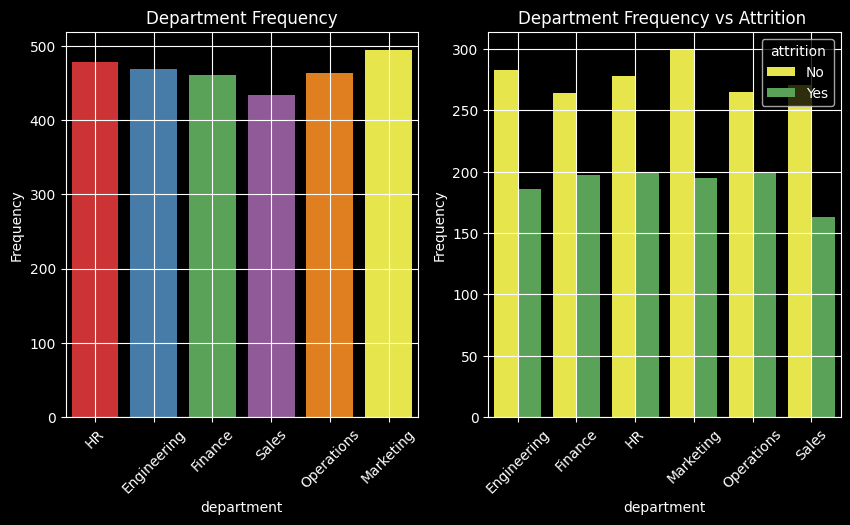

In [11]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.countplot(x="department",data=data,palette="Set1")
plt.title("Department Frequency",fontsize=12)
plt.grid(True)
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.subplot(1,2,2)
sns.barplot(x="department",y="Size",hue="attrition",data=df,palette="Set1_r")
plt.title("Department Frequency vs Attrition ",fontsize=12)
plt.grid(True)
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [12]:
data.role_level.value_counts().to_frame()

,count
role_level,
Senior,953
Mid,932
Junior,915


In [13]:
df = data.groupby(["attrition","department","role_level"]).size().reset_index(name="Size")
df

,attrition,department,role_level,Size
0,No,Engineering,Junior,90
1,No,Engineering,Mid,94
2,No,Engineering,Senior,99
3,No,Finance,Junior,86
4,No,Finance,Mid,91
5,No,Finance,Senior,87
6,No,HR,Junior,94
7,No,HR,Mid,89
8,No,HR,Senior,95
9,No,Marketing,Junior,92


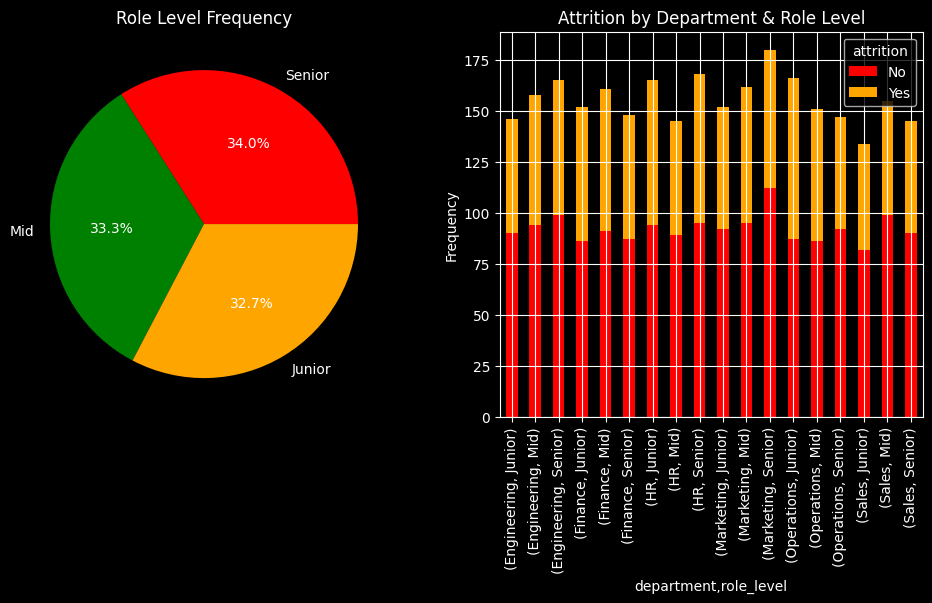

In [14]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.pie(x=data.role_level.value_counts().values,labels=data.role_level.value_counts().index,autopct="%1.1f%%",
        colors=["red","green","orange"])
plt.title("Role Level Frequency",fontsize=12)
plt.subplot(1,2,2)
pivot_df = df.pivot_table(index=["department","role_level"],columns="attrition",values="Size",fill_value=0)
pivot_df.plot(kind="bar",stacked=True,ax=plt.gca(),color=["red","orange"])
plt.title("Attrition by Department & Role Level")
plt.grid(True)
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.show()

In [15]:
min_salary = data["monthly_salary"].min()
max_salary = data["monthly_salary"].max()

print(f"Minimum Salary: {min_salary}")
print(f"Maximum Salary: {max_salary}")

Minimum Salary: 30006
Maximum Salary: 119977


In [16]:
df = data.groupby(["attrition", "department", "role_level"])["monthly_salary"].mean().reset_index()
df

,attrition,department,role_level,monthly_salary
0,No,Engineering,Junior,75011.222222
1,No,Engineering,Mid,76064.287234
2,No,Engineering,Senior,75108.151515
3,No,Finance,Junior,73502.011628
4,No,Finance,Mid,74643.450549
5,No,Finance,Senior,70510.505747
6,No,HR,Junior,75999.648936
7,No,HR,Mid,75321.764045
8,No,HR,Senior,70596.084211
9,No,Marketing,Junior,74530.554348


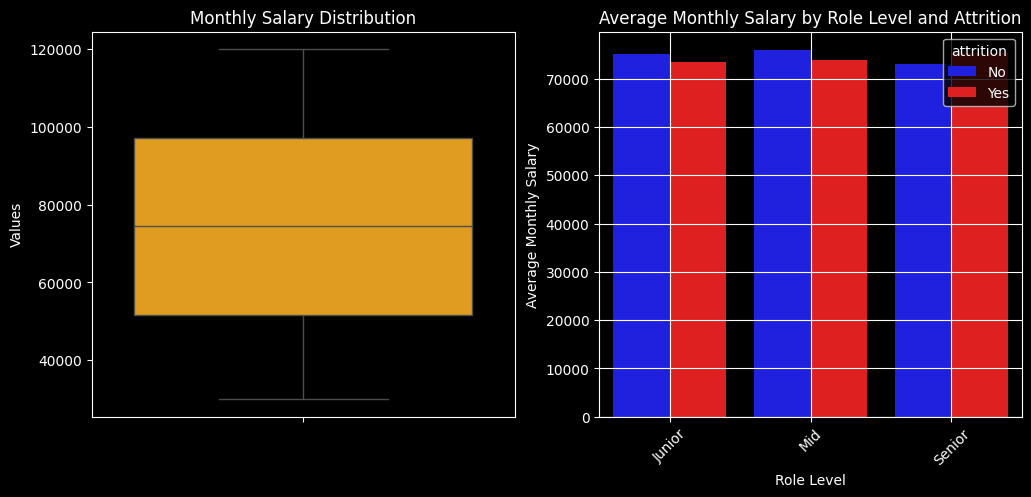

In [17]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(data=data,y="monthly_salary",color="orange")
plt.title("Monthly Salary Distribution",fontsize=12)
plt.ylabel("Values")
plt.subplot(1,2,2)
sns.barplot(data=df,x="role_level",y="monthly_salary",hue="attrition",palette={"No":"blue", "Yes":"red"},ci=None)
plt.title("Average Monthly Salary by Role Level and Attrition",fontsize=12)
plt.grid(True)
plt.xlabel("Role Level")
plt.ylabel("Average Monthly Salary")
plt.xticks(rotation=45)
plt.show()

In [18]:
min_hours = data["avg_weekly_hours"].min()
max_hours = data["avg_weekly_hours"].max()
print(f"Minimum Weekly Hours: {min_hours}")
print(f"Maximum Weekly Hours: {max_hours}")

Minimum Weekly Hours: 35
Maximum Weekly Hours: 65


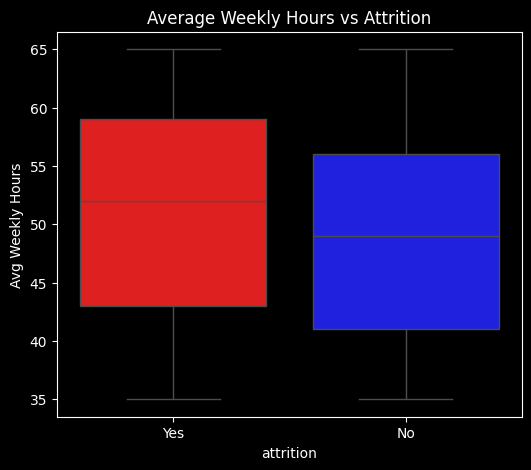

In [19]:
plt.figure(figsize=(6,5))
sns.boxplot(data=data, x="attrition", y="avg_weekly_hours", palette={"No":"blue", "Yes":"red"})
plt.title("Average Weekly Hours vs Attrition",fontsize=12)
plt.ylabel("Avg Weekly Hours")
plt.show()

In [20]:
data.projects_handled.value_counts().to_frame()

,count
projects_handled,
4,392
8,366
3,355
6,353
1,340
7,338
2,337
5,319


In [21]:
df = data.groupby(["attrition", "department", "role_level", 
                   "projects_handled"]).size().reset_index(name="employee_count")
df

,attrition,department,role_level,projects_handled,employee_count
0,No,Engineering,Junior,1,9
1,No,Engineering,Junior,2,17
2,No,Engineering,Junior,3,14
3,No,Engineering,Junior,4,9
4,No,Engineering,Junior,5,10
...,...,...,...,...,...
283,Yes,Sales,Senior,4,7
284,Yes,Sales,Senior,5,6
285,Yes,Sales,Senior,6,9
286,Yes,Sales,Senior,7,7


In [22]:
top5_df = df.groupby("attrition", group_keys=False).apply(
    lambda x: x.sort_values("employee_count", ascending=False).head(5)
)
top5_df

,attrition,department,role_level,projects_handled,employee_count
90,No,Marketing,Senior,3,19
131,No,Sales,Mid,4,19
21,No,Engineering,Senior,6,19
50,No,HR,Junior,3,18
128,No,Sales,Mid,1,18
233,Yes,Marketing,Senior,2,16
242,Yes,Operations,Junior,3,16
209,Yes,HR,Senior,2,16
167,Yes,Engineering,Senior,8,14
229,Yes,Marketing,Mid,6,14


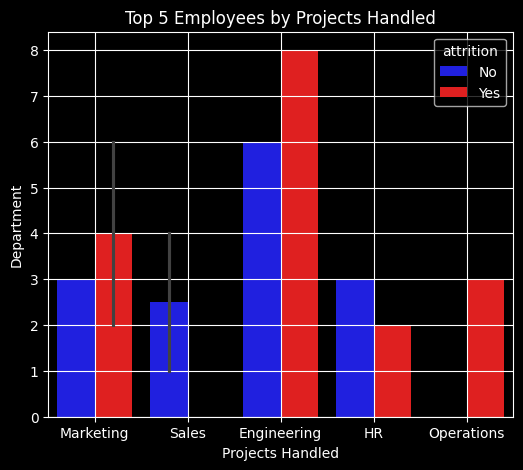

In [23]:
top5_projects = data.nlargest(5, "projects_handled")
plt.figure(figsize=(6,5))
sns.barplot(
    data=top5_df,
    y="projects_handled",
    x="department", 
    hue="attrition",
    palette={"No":"blue", "Yes":"red"}
)
plt.title("Top 5 Employees by Projects Handled",fontsize=12)
plt.grid(True)
plt.xlabel("Projects Handled")
plt.ylabel("Department")
plt.show()

In [24]:
data.performance_rating.value_counts()

performance_rating
3    587
1    574
2    566
4    542
5    531
Name: count, dtype: int64

In [25]:
df = data.groupby(
    ["attrition", "department", "role_level", "performance_rating"]
).size().reset_index(name="employee_count")
df

,attrition,department,role_level,performance_rating,employee_count
0,No,Engineering,Junior,1,16
1,No,Engineering,Junior,2,20
2,No,Engineering,Junior,3,18
3,No,Engineering,Junior,4,20
4,No,Engineering,Junior,5,16
...,...,...,...,...,...
175,Yes,Sales,Senior,1,12
176,Yes,Sales,Senior,2,15
177,Yes,Sales,Senior,3,10
178,Yes,Sales,Senior,4,9


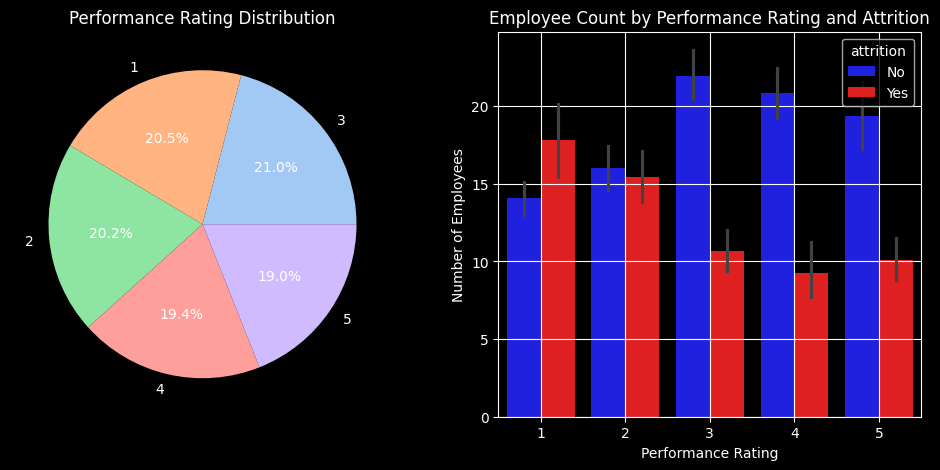

In [26]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.pie(
    x=data["performance_rating"].value_counts().values,
    labels=data["performance_rating"].value_counts().index,
    autopct="%1.1f%%",
    colors=sns.color_palette("pastel")
)
plt.title("Performance Rating Distribution",fontsize=12)
plt.subplot(1,2,2)
sns.barplot(
    data=df,
    x="performance_rating",
    y="employee_count",
    hue="attrition",
    palette={"No":"blue", "Yes":"red"}
)
plt.title("Employee Count by Performance Rating and Attrition",fontsize=12)
plt.grid(True)
plt.xlabel("Performance Rating")
plt.ylabel("Number of Employees")
plt.show()

In [27]:
min_absence = data["absences_days"].min()
max_absence = data["absences_days"].max()
print(f"Minimum Absence Days: {min_absence}")
print(f"Maximum Absence Days: {max_absence}")

Minimum Absence Days: 0
Maximum Absence Days: 20


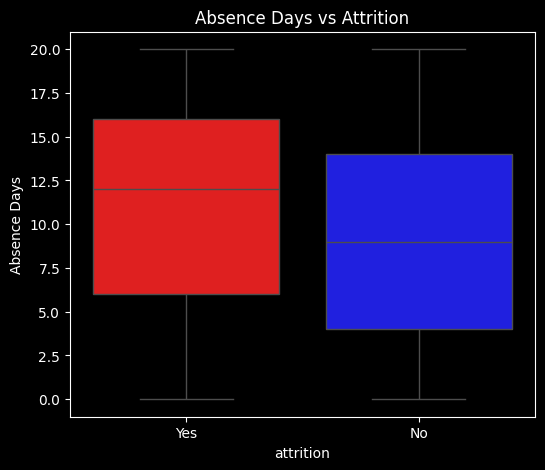

In [28]:
plt.figure(figsize=(6,5))
sns.boxplot(data=data, x="attrition", y="absences_days", palette={"No":"blue", "Yes":"red"})
plt.title("Absence Days vs Attrition",fontsize=12)
plt.ylabel("Absence Days")
plt.show()

In [29]:
data.job_satisfaction.value_counts().to_frame()

,count
job_satisfaction,
2,624
5,571
4,543
1,537
3,525


In [30]:
df = data.groupby(
    ["attrition", "department", "role_level", "job_satisfaction"]
).size().reset_index(name="employee_count")
df

,attrition,department,role_level,job_satisfaction,employee_count
0,No,Engineering,Junior,1,14
1,No,Engineering,Junior,2,14
2,No,Engineering,Junior,3,22
3,No,Engineering,Junior,4,19
4,No,Engineering,Junior,5,21
...,...,...,...,...,...
175,Yes,Sales,Senior,1,14
176,Yes,Sales,Senior,2,19
177,Yes,Sales,Senior,3,8
178,Yes,Sales,Senior,4,10


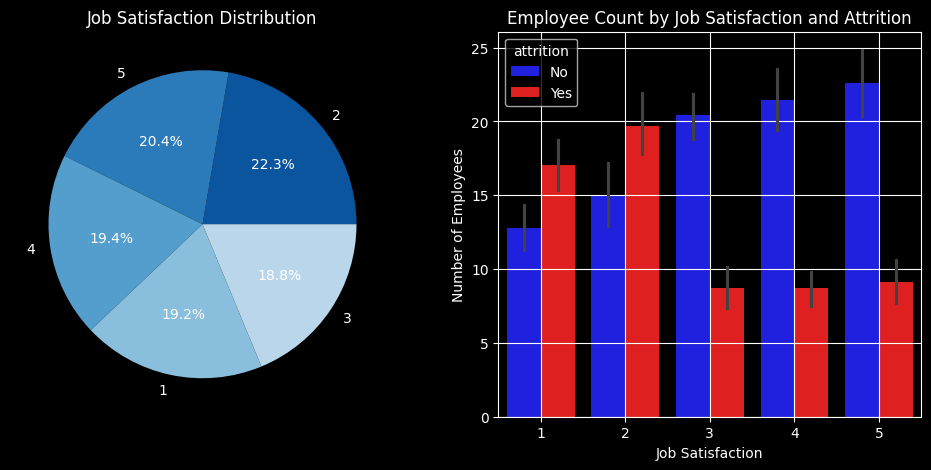

In [31]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.pie(
    x=data["job_satisfaction"].value_counts().values,
    labels=data["job_satisfaction"].value_counts().index,
    autopct="%1.1f%%",
    colors=sns.color_palette("Blues_r")
)
plt.title("Job Satisfaction Distribution",fontsize=12)
plt.subplot(1,2,2)
sns.barplot(
    data=df,
    x="job_satisfaction",
    y="employee_count",
    hue="attrition",
    palette={"No":"blue", "Yes":"red"}
)
plt.title("Employee Count by Job Satisfaction and Attrition",fontsize=12)
plt.grid(True)
plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Employees")
plt.show()

In [32]:
data.attrition.value_counts().to_frame()

,count
attrition,
No,1660
Yes,1140


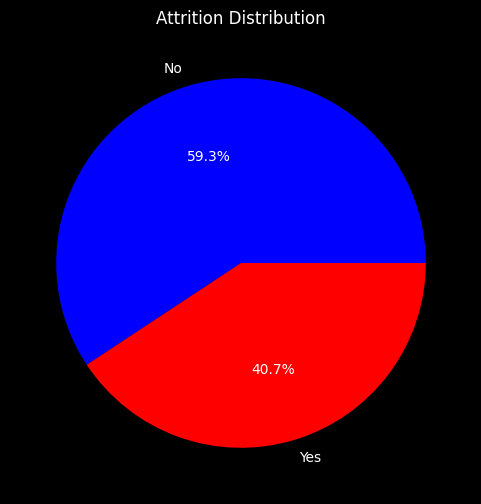

In [33]:
plt.figure(figsize=(6,6))
plt.pie(
    x=data.attrition.value_counts().values,
    labels=data.attrition.value_counts().index,
    autopct="%1.1f%%",
    colors=["blue","red"] 
)
plt.title("Attrition Distribution",fontsize=12)
plt.show()

****
**Preprocessing**
****

In [34]:
categorical_columns = data.select_dtypes(include="O").columns
categorical_columns

Index(['department', 'role_level', 'attrition'], dtype='object')

In [35]:
encoder = LabelEncoder()
for column in categorical_columns:
    data[column] = encoder.fit_transform(data[column])
data.head()

,employee_id,department,role_level,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction,attrition
0,1,2,0,81750,55,1,1,17,1,1
1,2,0,2,58140,36,2,4,13,1,1
2,3,1,1,37747,61,2,2,20,5,0
3,4,1,2,81993,36,4,1,17,2,1
4,5,5,2,45439,53,5,5,5,1,0


In [36]:
corr = data.corr()
corr

,employee_id,department,role_level,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction,attrition
employee_id,1.000000,-0.037354,-0.043933,0.009232,0.009321,-0.005626,0.029822,0.033080,0.056429,-0.019922
department,-0.037354,1.000000,-0.007514,0.013263,0.003836,-0.015285,-0.015067,-0.016272,0.005413,-0.011405
role_level,-0.043933,-0.007514,1.000000,-0.007116,-0.039790,0.021091,0.007315,0.019151,-0.028088,-0.019112
monthly_salary,0.009232,0.013263,-0.007116,1.000000,0.029115,-0.019332,-0.022908,-0.011762,0.013324,-0.008636
avg_weekly_hours,0.009321,0.003836,-0.039790,0.029115,1.000000,-0.029034,-0.015273,0.004734,-0.017721,0.109173
projects_handled,-0.005626,-0.015285,0.021091,-0.019332,-0.029034,1.000000,0.002238,0.007152,-0.058574,0.012404
performance_rating,0.029822,-0.015067,0.007315,-0.022908,-0.015273,0.002238,1.000000,-0.016273,-0.000991,-0.178151
absences_days,0.033080,-0.016272,0.019151,-0.011762,0.004734,0.007152,-0.016273,1.000000,-0.020231,0.162623
job_satisfaction,0.056429,0.005413,-0.028088,0.013324,-0.017721,-0.058574,-0.000991,-0.020231,1.000000,-0.246088
attrition,-0.019922,-0.011405,-0.019112,-0.008636,0.109173,0.012404,-0.178151,0.162623,-0.246088,1.000000


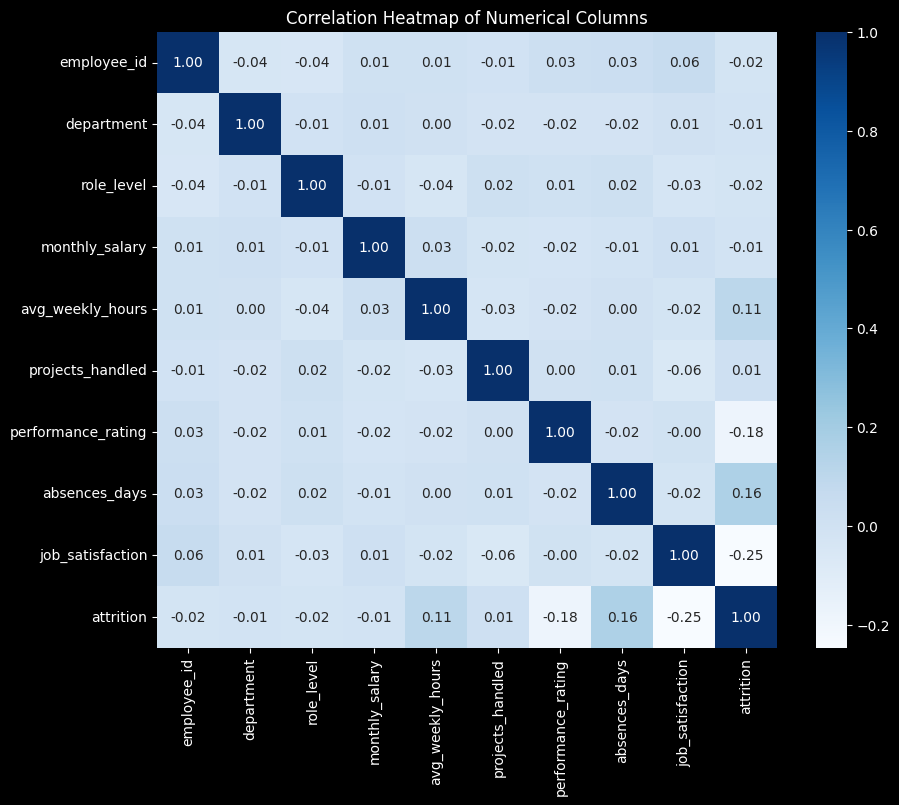

In [37]:
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,      
    cmap="Blues", 
    fmt=".2f" 
)
plt.title("Correlation Heatmap of Numerical Columns",fontsize=12)
plt.show()

In [38]:
corr_attrition = corr.attrition.drop("attrition")
corr_attrition

employee_id          -0.019922
department           -0.011405
role_level           -0.019112
monthly_salary       -0.008636
avg_weekly_hours      0.109173
projects_handled      0.012404
performance_rating   -0.178151
absences_days         0.162623
job_satisfaction     -0.246088
Name: attrition, dtype: float64

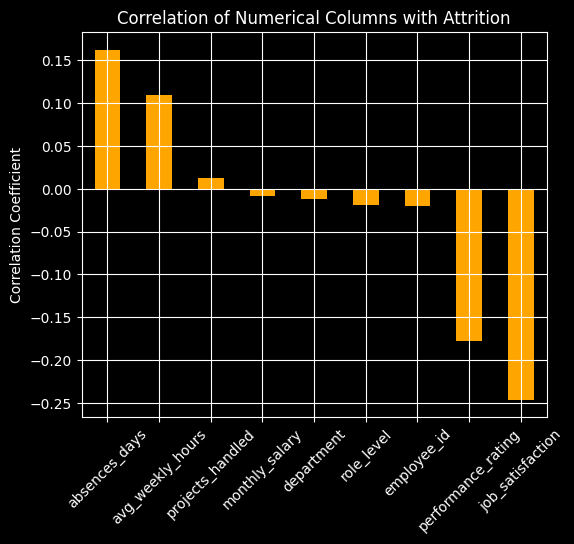

In [39]:
plt.figure(figsize=(6,5))
corr_attrition.sort_values(ascending=False).plot(kind="bar", color="orange")
plt.title("Correlation of Numerical Columns with Attrition",fontsize=12)
plt.grid(True)
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=45)
plt.show()

In [40]:
scaler = MinMaxScaler()
data = pd.DataFrame(scaler.fit_transform(data),columns=data.columns)
data.head()

,employee_id,department,role_level,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction,attrition
0,0.000000,0.4,0.0,0.575119,0.666667,0.000000,0.00,0.85,0.00,1.0
1,0.000357,0.0,1.0,0.312701,0.033333,0.142857,0.75,0.65,0.00,1.0
2,0.000715,0.2,0.5,0.086039,0.866667,0.142857,0.25,1.00,1.00,0.0
3,0.001072,0.2,1.0,0.577820,0.033333,0.428571,0.00,0.85,0.25,1.0
4,0.001429,1.0,1.0,0.171533,0.600000,0.571429,1.00,0.25,0.00,0.0


In [41]:
X = data.iloc[:,1:-1]
y = data.attrition.astype(int)
X.head()

,department,role_level,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction
0,0.4,0.0,0.575119,0.666667,0.000000,0.00,0.85,0.00
1,0.0,1.0,0.312701,0.033333,0.142857,0.75,0.65,0.00
2,0.2,0.5,0.086039,0.866667,0.142857,0.25,1.00,1.00
3,0.2,1.0,0.577820,0.033333,0.428571,0.00,0.85,0.25
4,1.0,1.0,0.171533,0.600000,0.571429,1.00,0.25,0.00


In [42]:
y.head()

0    1
1    1
2    0
3    1
4    0
Name: attrition, dtype: int64

In [43]:
over_sampling = RandomUnderSampler()
X,y = over_sampling.fit_resample(X,y)

In [44]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,shuffle=True,random_state=44)
print(f"Training Input Size: {X_train.shape} , Training Output Size: {y_train.shape}")
print(f"Testing Input Size: {X_test.shape} , Testing Output Size: {y_test.shape}")

Training Input Size: (1824, 8) , Training Output Size: (1824,)
Testing Input Size: (456, 8) , Testing Output Size: (456,)


****
**ML Models**
****

In [45]:
models = {
    "RandomForest": [
        RandomForestClassifier(random_state=42),
        {"n_estimators":[200,300,500,1000], "max_depth":[None,10,20,30,50]}
    ],
    "DecisionTree": [
        DecisionTreeClassifier(random_state=42),
        {"max_depth":[None,10,20,30,50], "min_samples_split":[2,5,10]}
    ],
    "KNN": [
        KNeighborsClassifier(),
        {"n_neighbors":[3,5,7], "weights":["uniform","distance"]}
    ],
    "XGBoost": [
        XGBRFClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
        {"n_estimators":[200,300,500,1000], "max_depth":[None,10,20,30,50]}
    ],
    "LightGBM": [
        LGBMClassifier(random_state=42),
        {"n_estimators":[200,300,500,1000], "max_depth":[None,10,20,30,50]}
    ],
    "CatBoost": [
        CatBoostClassifier(random_state=42, verbose=0),
        {"depth":[10,20,30,50], "iterations":[300,500,1000]}
    ]
}

results = []

for name, (model, params) in models.items():
    print(f"Training {name}...")
    
    if params:
        grid = GridSearchCV(model, param_grid=params, cv=5, scoring="accuracy", n_jobs=-1)
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        best_params = grid.best_params_
    else:
        model.fit(X_train, y_train)
        best_model = model
        best_params = "No params"
    
    train_score = best_model.score(X_train, y_train)
    test_score = best_model.score(X_test, y_test)
    
    results.append({
        "Model": name,
        "Train Score": train_score,
        "Test Score": test_score,
        "Best Params": best_params,
        "Best Estimator": best_model
    })

Training RandomForest...
Training DecisionTree...
Training KNN...
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:31:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:31:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:31:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:31:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:31:41] WARNING: /w

Training LightGBM...
[LightGBM] [Info] Number of positive: 728, number of negative: 731
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007999 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 334
[LightGBM] [Info] Number of data points in the train set: 1459, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498972 -> initscore=-0.004112
[LightGBM] [Info] Start training from score -0.004112
[LightGBM] [Info] Number of positive: 728, number of negative: 731
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002036 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 334
[LightGBM] [Info] Number of data points in the train set: 1459, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498972 -> initscore=-0.00

In [46]:
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by="Test Score", ascending=False)
results_df_sorted

,Model,Train Score,Test Score,Best Params,Best Estimator
3,XGBoost,0.762061,0.695175,"{'max_depth': None, 'n_estimators': 200}","XGBRFClassifier(base_score=None, booster=None,..."
0,RandomForest,0.979167,0.677632,"{'max_depth': 10, 'n_estimators': 1000}","(DecisionTreeClassifier(max_depth=10, max_feat..."
4,LightGBM,1.000000,0.666667,"{'max_depth': 10, 'n_estimators': 300}","LGBMClassifier(max_depth=10, n_estimators=300,..."
5,CatBoost,1.000000,0.644737,"{'depth': 10, 'iterations': 300}",<catboost.core.CatBoostClassifier object at 0x...
2,KNN,0.718202,0.607456,"{'n_neighbors': 7, 'weights': 'uniform'}",KNeighborsClassifier(n_neighbors=7)
1,DecisionTree,0.904605,0.585526,"{'max_depth': 10, 'min_samples_split': 2}","DecisionTreeClassifier(max_depth=10, random_st..."


In [47]:
best_model_row = results_df_sorted.iloc[0]
best_estimator = best_model_row["Best Estimator"]
best_model_name = best_model_row["Model"]
best_test_score = best_model_row["Test Score"]

print(f"Best Model: {best_model_name}")
print(f"Test Score: {best_test_score}")
print("Best Estimator Object:", best_estimator)

Best Model: XGBoost
Test Score: 0.6951754385964912
Best Estimator Object: XGBRFClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bytree=None, device=None,
                early_stopping_rounds=None, enable_categorical=False,
                eval_metric='logloss', feature_types=None, feature_weights=None,
                gamma=None, grow_policy=None, importance_type=None,
                interaction_constraints=None, max_bin=None,
                max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=None, max_leaves=None,
                min_child_weight=None, missing=nan, monotone_constraints=None,
                multi_strategy=None, n_estimators=200, n_jobs=None,
                num_parallel_tree=None, objective='binary:logistic',
                random_state=42, ...)


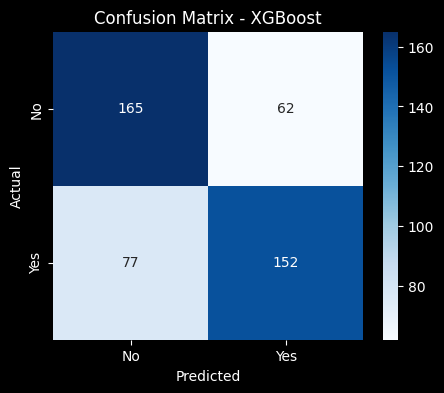

Classification Report - XGBoost:

              precision    recall  f1-score   support

          No       0.68      0.73      0.70       227
         Yes       0.71      0.66      0.69       229

    accuracy                           0.70       456
   macro avg       0.70      0.70      0.69       456
weighted avg       0.70      0.70      0.69       456



In [48]:
# -------- Predict using best estimator --------
y_pred = best_estimator.predict(X_test)

# -------- Confusion Matrix --------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No","Yes"], yticklabels=["No","Yes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

# -------- Classification Report --------
print(f"Classification Report - {best_model_name}:\n")
print(classification_report(y_test, y_pred,target_names=["No","Yes"]))
